In [46]:
import pandas as pd 
import numpy as np
import joblib

In [59]:
model = joblib.load("/Users/skush/CodeX/Stress-Level-Classifier/models/random_forest_87.pkl")
scaler = joblib.load("/Users/skush/CodeX/Stress-Level-Classifier/models/scaler.pkl")

# Load training feature columns (saved during training)
training_columns = joblib.load("/Users/skush/CodeX/Stress-Level-Classifier/models/features.pkl")

In [48]:
new_data = pd.read_csv("/Users/skush/CodeX/Stress-Level-Classifier/data/processed/survey_data_labelled.csv")
new_data = new_data.loc[:, ~new_data.columns.str.contains('^Unnamed')]

In [49]:
new_data.head()

,Age,Work_Productivity_Score,Weekend_Screen_Time_Hours,Daily_Screen_Hours,Sleep_Hours,Social_Media_Hours,Stress_Level,Caffeine_Cups_Per_Day,Stressed,Gender_female,Gender_male,Occupation_professional,Occupation_student
0,22,6,4.0,4.0,7.0,1.5,7,3,1,False,True,False,True
1,23,9,2.5,2.0,7.0,0.5,2,0,0,True,False,False,True
2,23,6,6.0,4.0,7.5,3.0,4,3,0,True,False,False,True
3,23,6,6.0,4.0,7.5,3.0,4,3,0,True,False,True,False
4,23,6,4.5,3.0,8.0,2.0,5,1,0,False,True,False,True


In [50]:
X_test = new_data.drop(columns="Stressed")
y_test = new_data["Stressed"]

In [51]:
def align_features(data, training_columns):
    
    # Add missing columns
    for col in training_columns:
        if col not in data.columns:
            data[col] = 0
    
    # Remove extra columns
    data = data[training_columns]
    
    return data

In [52]:
aligned_data = align_features(new_data, training_columns)

In [53]:
aligned_data

,Age,Sleep_Hours,Daily_Screen_Hours,Social_Media_Hours,Caffeine_Cups_Per_Day,Work_Productivity_Score,App_Usage_Count,Exercise_Hours_Per_Week,Daily_Work_Hours,Commute_Hours_Per_Day,Gender_male,Gender_other,Occupation_freelancer,Occupation_healthcare worker,Occupation_retired,Occupation_student,Occupation_teacher,Occupation_young professional
0,22,7.0,4.0,1.5,3,6,0,0,0,0,True,0,0,0,0,True,0,0
1,23,7.0,2.0,0.5,0,9,0,0,0,0,False,0,0,0,0,True,0,0
2,23,7.5,4.0,3.0,3,6,0,0,0,0,False,0,0,0,0,True,0,0
3,23,7.5,4.0,3.0,3,6,0,0,0,0,False,0,0,0,0,False,0,0
4,23,8.0,3.0,2.0,1,6,0,0,0,0,True,0,0,0,0,True,0,0
5,24,6.5,7.0,5.0,0,10,0,0,0,0,False,0,0,0,0,True,0,0
6,22,6.5,3.0,2.0,0,5,0,0,0,0,False,0,0,0,0,True,0,0
7,22,8.5,4.5,3.5,1,4,0,0,0,0,False,0,0,0,0,True,0,0
8,26,8.0,3.0,4.0,1,7,0,0,0,0,False,0,0,0,0,True,0,0
9,29,7.0,8.0,7.0,2,8,0,0,0,0,False,0,0,0,0,True,0,0


In [54]:
aligned_data = aligned_data.fillna(0)

In [55]:
scaled_data = scaler.transform(aligned_data)

In [60]:
predictions = model.predict(scaled_data)

In [61]:
from sklearn.metrics import classification_report, accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Random Forest Accuracy: 0.5423728813559322
              precision    recall  f1-score   support

           0       0.38      0.88      0.53        17
           1       0.89      0.40      0.56        42

    accuracy                           0.54        59
   macro avg       0.63      0.64      0.54        59
weighted avg       0.74      0.54      0.55        59



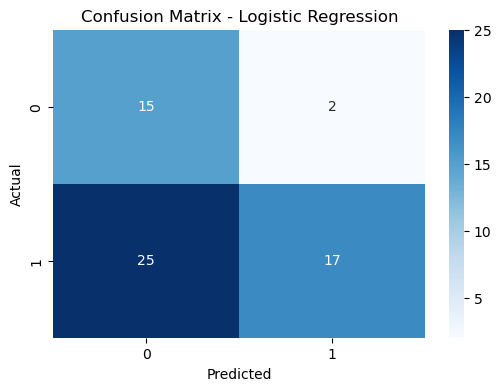

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

<h4>  GB

In [63]:
model = joblib.load("/Users/skush/CodeX/Stress-Level-Classifier/models/gradient_boost_86.pkl")

In [64]:
predictions = model.predict(scaled_data)

In [65]:
from sklearn.metrics import classification_report, accuracy_score

print("Gradient Boosting Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Gradient Boosting Accuracy: 0.4576271186440678
              precision    recall  f1-score   support

           0       0.33      0.88      0.48        17
           1       0.86      0.29      0.43        42

    accuracy                           0.46        59
   macro avg       0.60      0.58      0.46        59
weighted avg       0.71      0.46      0.44        59



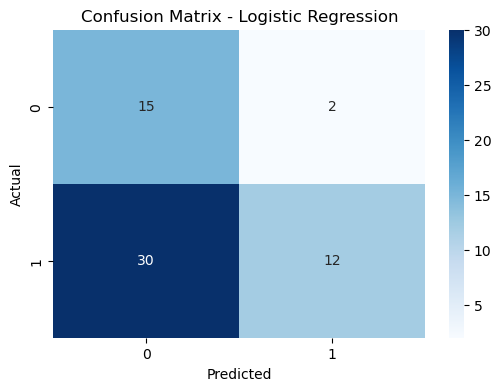

In [66]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

<h3> SVM

In [67]:
model = joblib.load("/Users/skush/CodeX/Stress-Level-Classifier/models/svm_84.pkl")

In [68]:
predictions = model.predict(scaled_data)
from sklearn.metrics import classification_report, accuracy_score

print("Gradient Boosting Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Gradient Boosting Accuracy: 0.5932203389830508
              precision    recall  f1-score   support

           0       0.39      0.76      0.52        17
           1       0.85      0.52      0.65        42

    accuracy                           0.59        59
   macro avg       0.62      0.64      0.58        59
weighted avg       0.72      0.59      0.61        59



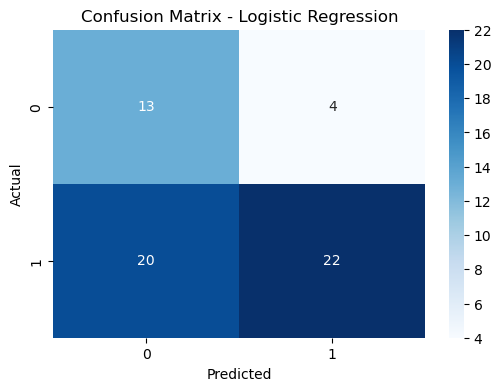

In [69]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

<h3> KNN

In [70]:
model = joblib.load("/Users/skush/CodeX/Stress-Level-Classifier/models/knn_81.pkl")

In [71]:
predictions = model.predict(scaled_data)
from sklearn.metrics import classification_report, accuracy_score

print("Gradient Boosting Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Gradient Boosting Accuracy: 0.6101694915254238
              precision    recall  f1-score   support

           0       0.40      0.71      0.51        17
           1       0.83      0.57      0.68        42

    accuracy                           0.61        59
   macro avg       0.61      0.64      0.59        59
weighted avg       0.70      0.61      0.63        59



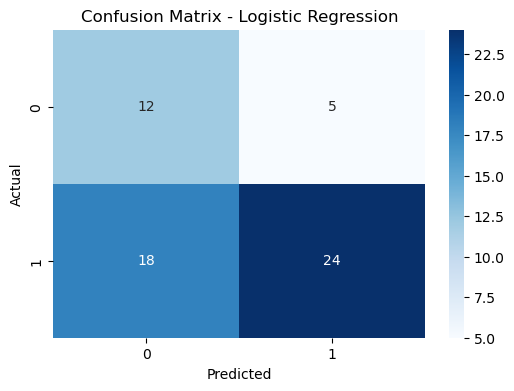

In [72]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

<h3> Logistic Regression

In [73]:
model = joblib.load("/Users/skush/CodeX/Stress-Level-Classifier/models/baseline.pkl")

In [ ]:
predictions = model.predict(scaled_data)
from sklearn.metrics import classification_report, accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Gradient Boosting Accuracy: 0.288135593220339
              precision    recall  f1-score   support

           0       0.29      1.00      0.45        17
           1       0.00      0.00      0.00        42

    accuracy                           0.29        59
   macro avg       0.14      0.50      0.22        59
weighted avg       0.08      0.29      0.13        59



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


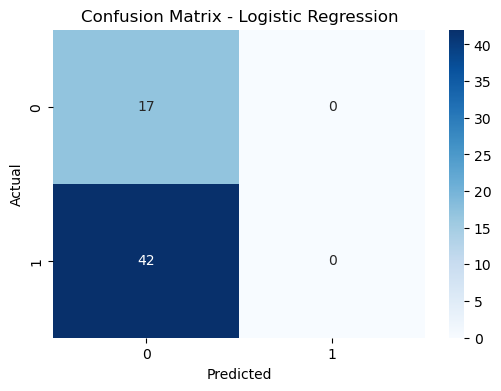

In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()